GPU Mixed Precision Training Available
VirtualDNA-Gen: AI-Generated DNA Sequences for Virtual Cells
Computing Device: cuda
Target Data Path: data/human.txt

1. Loading and Preparing Data
Successfully loaded data: 4381 sequences
Raw Data Statistics:
Total sequences: 4381
Sequence length range: 5 - 18921
Base composition: A=25.3%, T=22.1%, C=26.3%, G=26.3%
GC content range: 0.12 - 0.78
GC content mean: 0.53

 Starting data cleaning and filtering...
  Original count: 4381
  Filtered count: 1429
  Dropped count: 2952 (67.4%)

Dataset Statistics:
  Final size: 1429
  Class distribution:
    Class 0: 137 sequences (9.6%)
    Class 1: 187 sequences (13.1%)
    Class 2: 120 sequences (8.4%)
    Class 3: 267 sequences (18.7%)
    Class 4: 278 sequences (19.5%)
    Class 5: 59 sequences (4.1%)
    Class 6: 381 sequences (26.7%)

  Sequence length stats:
    Mean: 304.5 bp
    Min: 50 bp
    Max: 500 bp

Building Vocabulary (k=6)...
[Vocab] Size: 4100 (k=6)
Number of classes: 7
Class mapping: {'4

Epoch 54/80: 100%|██████████| 9/9 [00:01<00:00,  4.89it/s, loss=0.124, acc=96.2]


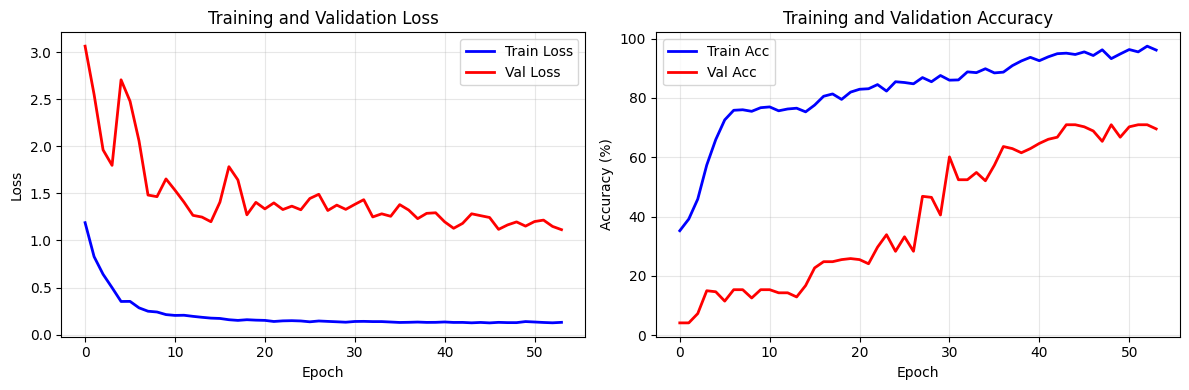

Training results saved to output/training_plots/training_curves.png

Initializing DNA Generator

3. Training DNA Generator


Epoch 80: 100%|██████████| 9/9 [00:02<00:00,  3.73it/s, CE=0.00689, Guide=0.0745]



4. Generating DNA Sequences
  [1] TTCGCATGGAGTATTGTGTGACACATCGAGGCATTTGCTAAAGCCTTTAC... (Len: 205)
  [2] TGATTTTGAAAAGAAGCTGCCGATTTCTCTATCATCAATAGCCTGAGGGG... (Len: 105)
  [3] TTCGCATCATGGCTTTGTGAAAGAAACCAAAGACTGGCTGGCATCAATAG... (Len: 205)
  [4] TTCGCATGGCATCTCTCTATGTTCTTGATATTCCTACCTCTCCTTCAGCT... (Len: 205)
  [5] TTCGCATGGAGTGGTCAAGGAAGCTGCCGCTTGCTTTCAAGAAGTATAAA... (Len: 205)
  [6] TTCGCATGGAGTGGCGCGAGACCGTTGGGGGAGGGCACCCCCGAGCCGCG... (Len: 205)
  [7] TTCGCATGGCATCTCCTTCAGGCAAGGCTAATCCTTTCGCCACAGTGCTG... (Len: 205)
  [8] TTCGCATCATGTTCTTGTGGCCCCTGCCACCGAGGACCAGTACTACATCC... (Len: 205)
  [9] CGAGAGCAGACCCTCCTTCAGCTACTCCATCAATAGCCTAACCAAGGTTC... (Len: 123)
  [10] TTCGCATGGAGTGGTGAGGGTCTTTGGGGAGGGGCAGGACAAGGACGCGG... (Len: 205)
  [1] CGAGAGCAGACTGCGACTCGCTCCAGTTTCCTTTACTGTAACTGCAGCTA... (Len: 128)
  [2] CGAGAGCGGGATTTGGGGTATTTCATCAATAGTCCCCCCGACTCAGCATC... (Len: 205)
  [3] TTCGCATGGCTTTCAAGATACACGCCATGAAGAGGGAAAGCCTTACCCAG... (Len: 205)
  [4] TTCGCATGATTATAGAGCTATCACTGATGGGAAGAAGTTTC

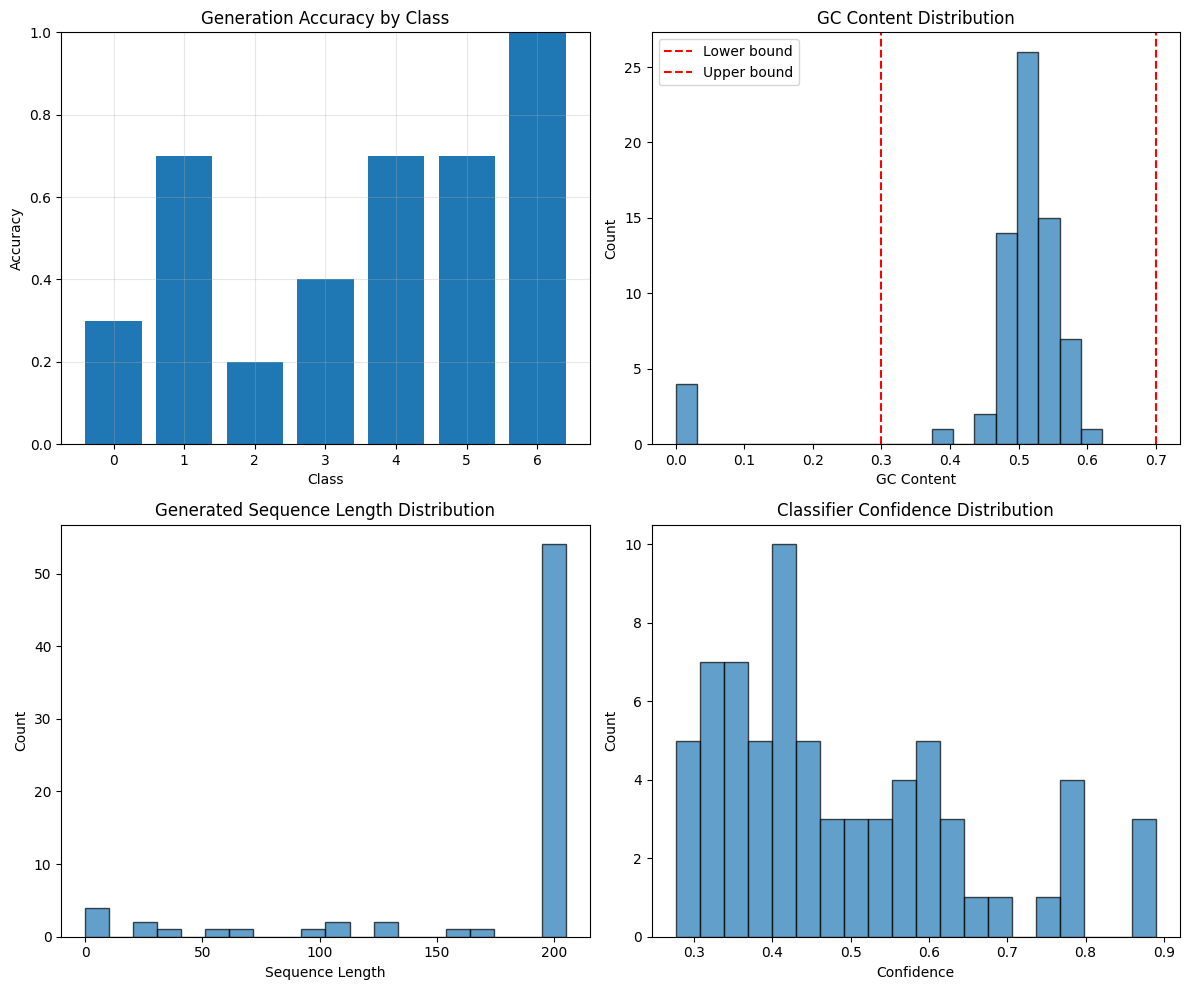

Visualization plots saved to: output/training_plots/generation_results.png
Final report saved to: output/final_report.json
Human-readable report saved to: output/final_report.txt

Outputs located in 'output/' directory

Key Performance Indicators (KPI):
Final Validation Accuracy: 69.58%
Synthetic Sequence Accuracy: 57.14%
GC Content Validity Ratio: 94.29%


In [2]:
#!/usr/bin/env python3
"""
VirtualDNA-Gen: AI-Generated DNA Sequences for Virtual Cells
Full Implementation: Data Prep → Model Building → Training → Generation → Evaluation
"""
import os
import sys
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import json
from typing import List, Dict, Tuple, Optional
from collections import Counter
import warnings

try:
    from torch.cuda.amp import autocast, GradScaler

    AMP_AVAILABLE = True
    print("GPU Mixed Precision Training Available")
except ImportError:
    AMP_AVAILABLE = False
    print("GPU Mixed Precision Training Not Available, using standard precision")

warnings.filterwarnings('ignore')


# Set Random Seed
def set_seed(seed: int = 42):
    """Ensure reproducible results across run"""
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

# Hyperparameter Configuration
class Config:
    """Project global settings and hyperparameters"""
    # Data parameters
    data_path = "data/human.txt"
    k_mer = 6
    max_seq_len = 200
    # Model parameters
    embed_dim = 128
    num_heads = 8
    num_layers = 4
    dropout = 0.5
    num_classes = 7
    label_smoothing = 0.1
    # Training parameters
    batch_size = 128
    learning_rate = 1e-2
    weight_decay = 1e-4
    epochs = 80
    patience = 10
    # Generation parameters
    generation_temperature = 0.9
    top_k = 10
    generation_max_len = 200
    # Device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    # Paths
    output_dir = "output"
    model_save_path = os.path.join(output_dir, "model_checkpoints")
    plot_save_path = os.path.join(output_dir, "training_plots")
    generation_seqs_path = os.path.join(output_dir, "generated_seqs")

    def __init__(self):
        """Create output directories"""
        os.makedirs(self.output_dir, exist_ok=True)
        os.makedirs(self.model_save_path, exist_ok=True)
        os.makedirs(self.plot_save_path, exist_ok=True)
        os.makedirs(self.generation_seqs_path, exist_ok=True)
        # Check if data file exists
        if not os.path.exists(self.data_path):
            print(f"Error: Data file {self.data_path} not found")
            print("Please ensure human.txt is placed in the data/ folder")
            sys.exit(1)

# =Data Preparation
class DNAVocab:
    """DNA Sequence k-mer Vocabulary"""
    def __init__(self, k=3):
        self.k = k
        self.vocab = {}
        self.idx_to_token = {}
        self.special_tokens = ['<PAD>', '<UNK>', '<CLS>', '<SEP>', '<MASK>']

    def build(self, sequences: List[str]) -> 'DNAVocab':
        """Build vocabulary from sequences"""
        all_kmers = set()
        for seq in sequences:
            seq = seq.upper()
            for i in range(len(seq) - self.k + 1):
                kmer = seq[i:i + self.k]
                all_kmers.add(kmer)

        for i, token in enumerate(self.special_tokens):
            self.vocab[token] = i

        for i, kmer in enumerate(sorted(all_kmers)):
            self.vocab[kmer] = i + len(self.special_tokens)

        self.idx_to_token = {idx: token for token, idx in self.vocab.items()}
        print(f"[Vocab] Size: {len(self.vocab)} (k={self.k})")
        return self

    def encode(self, sequence: str, max_len: int = 200) -> List[int]:
        """Encode DNA sequence"""
        sequence = sequence.upper()
        tokens = []
        for i in range(len(sequence) - self.k + 1):
            kmer = sequence[i:i + self.k]
            tokens.append(self.vocab.get(kmer, self.vocab['<UNK>']))
        tokens.append(self.vocab['<SEP>'])

        if len(tokens) > max_len:
            tokens = tokens[:max_len]
        else:
            tokens = tokens + [self.vocab['<PAD>']] * (max_len - len(tokens))
        return tokens

    def decode(self, token_ids: List[int]) -> str:
        """Decode token IDs back to DNA sequence"""
        sequence = ''
        for i, token_id in enumerate(token_ids):
            if token_id in self.idx_to_token:
                token = self.idx_to_token[token_id]
                if token not in self.special_tokens:
                    if i == 0:
                        sequence += token
                    else:
                        sequence += token[-1]
        return sequence

    def __len__(self) -> int:
        return len(self.vocab)


class DNADataset(Dataset):
    """DNA Sequence Dataset"""

    def __init__(self, sequences: List[str], labels: List[int],vocab: DNAVocab, max_len: int = 200):
        self.sequences = sequences
        self.labels = labels
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self) -> int:
        return len(self.sequences)

    def __getitem__(self, idx: int) -> Dict:
        sequence = self.sequences[idx]
        label = self.labels[idx]
        tokens = self.vocab.encode(sequence, self.max_len)
        return {
            'input_ids': torch.tensor(tokens, dtype=torch.long),
            'labels': torch.tensor(label, dtype=torch.long),
            'attention_mask': torch.tensor(
                [1 if x != self.vocab.vocab['<PAD>'] else 0 for x in tokens]
            )
        }


def load_and_prepare_data(config: Config) -> Tuple:
    """Load and prepare data"""
    print("\n" + "=" * 50)
    print("1. Loading and Preparing Data")
    print("=" * 50)

    try:
        df = pd.read_table(config.data_path, header=None)
        df.columns = ['sequence', 'class']
        print(f"Successfully loaded data: {len(df)} sequences")
    except Exception as e:
        print(f"Failed to load data: {e}")
        sys.exit(1)

    print("Raw Data Statistics:")
    print(f"Total sequences: {len(df)}")
    print(f"Sequence length range: {df['sequence'].str.len().min()} - {df['sequence'].str.len().max()}")

    all_seq = ''.join(df['sequence'].tolist()).upper()
    total_bases = len(all_seq)
    base_counts = {
        'A': all_seq.count('A') / total_bases * 100,
        'T': all_seq.count('T') / total_bases * 100,
        'C': all_seq.count('C') / total_bases * 100,
        'G': all_seq.count('G') / total_bases * 100
    }
    print(
        f"Base composition: A={base_counts['A']:.1f}%, T={base_counts['T']:.1f}%, C={base_counts['C']:.1f}%, G={base_counts['G']:.1f}%")

    df['gc_content'] = df['sequence'].apply(
        lambda x: (x.upper().count('G') + x.upper().count('C')) / len(x) if len(x) > 0 else 0)
    print(f"GC content range: {df['gc_content'].min():.2f} - {df['gc_content'].max():.2f}")
    print(f"GC content mean: {df['gc_content'].mean():.2f}")
    print(f"\n Starting data cleaning and filtering...")

    def clean_dna_sequence(sequence, min_len=50, max_len=500, gc_range=(0.3, 0.7)):
        """Validates sequence quality, length, and complexity"""
        if not isinstance(sequence, str):
            return None
        sequence = sequence.strip().upper()
        sequence = ''.join([base for base in sequence if base in 'ATCG'])
        if len(sequence) < min_len or len(sequence) > max_len:
            return None
        gc = (sequence.count('G') + sequence.count('C')) / len(sequence) if len(sequence) > 0 else 0
        if not (gc_range[0] <= gc <= gc_range[1]):
            return None
        # Filter low complexity sequences
        unique_kmers = len(set([sequence[i:i + 3] for i in range(len(sequence) - 2)]))
        if unique_kmers < len(sequence) * 0.1:
            return None
        return sequence
    # Apply cleanup logic
    original_count = len(df)
    df['sequence_clean'] = df['sequence'].apply(clean_dna_sequence)
    df_clean = df.dropna(subset=['sequence_clean']).copy()
    df_clean['sequence'] = df_clean['sequence_clean']
    df_clean = df_clean.drop(columns=['sequence_clean'])

    filtered_count = len(df_clean)
    print(f"  Original count: {original_count}")
    print(f"  Filtered count: {filtered_count}")
    print(
        f"  Dropped count: {original_count - filtered_count} ({100 * (original_count - filtered_count) / original_count:.1f}%)")

    if filtered_count == 0:
        print(" No valid data after filtering!")
        sys.exit(1)

    df = df_clean
    print(f"\nDataset Statistics:")
    print(f"  Final size: {len(df)}")
    print(f"  Class distribution:")
    class_counts = df['class'].value_counts().sort_index()
    for class_id, count in class_counts.items():
        print(f"    Class {class_id}: {count} sequences ({count / len(df) * 100:.1f}%)")

    df['seq_length'] = df['sequence'].apply(len)
    print(f"\n  Sequence length stats:")
    print(f"    Mean: {df['seq_length'].mean():.1f} bp")
    print(f"    Min: {df['seq_length'].min()} bp")
    print(f"    Max: {df['seq_length'].max()} bp")

    print(f"\nBuilding Vocabulary (k={config.k_mer})...")
    vocab = DNAVocab(k=config.k_mer)
    vocab.build(df['sequence'].tolist())

    class_counts = Counter(df['class'])
    valid_classes = [cls for cls, cnt in class_counts.items() if cnt >= 2]
    df = df[df['class'].isin(valid_classes)].reset_index(drop=True)

    unique_classes = df['class'].unique()
    class_to_idx = {cls: i for i, cls in enumerate(unique_classes)}
    df['class_encoded'] = df['class'].map(class_to_idx)

    config.CLASS_TO_IDX = class_to_idx
    config.IDX_TO_CLASS = {i: cls for cls, i in class_to_idx.items()}
    config.num_classes = len(class_to_idx)
    num_classes = config.num_classes
    print(f"Number of classes: {num_classes}")
    print(f"Class mapping: {class_to_idx}")

    if len(df) == 0:
        raise ValueError("No valid data after filtering!")

    # Stratified Split
    X_train, X_test, y_train, y_test = train_test_split(
        df['sequence'].tolist(),
        df['class_encoded'].tolist(),
        test_size=0.2,
        stratify=df['class_encoded'].tolist(),
        random_state=42
    )

    train_class_counts = Counter(y_train)
    total_train = len(y_train)
    print(f"Training set distribution:")
    for class_id in range(num_classes):
        count = train_class_counts.get(class_id, 0)
        if class_id in config.IDX_TO_CLASS:
            class_name = config.IDX_TO_CLASS[class_id]
            print(f"  Class {class_id}({class_name}): {count} samples ({count / total_train:.1%})")

    class_weights = {}
    for class_id, count in train_class_counts.items():
        if count > 0:
            weight = total_train / (num_classes * count)
            # Apply booster weights for specific classes
            if class_id == 5:
                weight *= 8.0
            elif class_id == 6:
                weight *= 8.0
                print(f"Enhanced weights for ID {class_id} ({config.IDX_TO_CLASS[class_id]})")
            class_weights[class_id] = weight
        else:
            class_weights[class_id] = 0.0

    print(f"Class weights: {class_weights}")
    sample_weights = [class_weights[label] for label in y_train]
    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(y_train),
        replacement=True
    )

    print(f"\n Verifying sampler effect...")
    sampler_indices = list(sampler)[:1000]
    sampled_labels = [y_train[idx] for idx in sampler_indices]
    sampled_counts = Counter(sampled_labels)
    print(f"Sampled distribution (first 1000):")
    for class_id in range(num_classes):
        count = sampled_counts.get(class_id, 0)
        if class_id in config.IDX_TO_CLASS:
            class_name = config.IDX_TO_CLASS[class_id]
            print(f"  Class {class_id}({class_name}): {count} ({count / len(sampled_labels):.1%})")

    train_dataset = DNADataset(X_train, y_train, vocab, config.max_seq_len)
    test_dataset = DNADataset(X_test, y_test, vocab, config.max_seq_len)

    train_loader = DataLoader(train_dataset, batch_size=config.batch_size, sampler=sampler, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=0)

    print(f"\nSplit Complete:")
    print(f"  Train: {len(train_dataset)} samples")
    print(f"  Test: {len(test_dataset)} samples")
    print(f"  Vocab Size: {len(vocab)}")
    return train_loader, test_loader, vocab, df, class_weights, num_classes


# Model Definitions
class RMSNorm(nn.Module):
    """RMS Normalization Layer"""
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

class RotaryPositionalEmbedding(nn.Module):
    """RoPE Positional Embedding"""
    def __init__(self, dim: int, num_heads: int):
        super().__init__()
        self.dim = dim
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.cache = {}
        assert dim % num_heads == 0, f"dim {dim} must be divisible by num_heads {num_heads}"
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        batch, seq_len, dim = x.shape
        x_reshaped = x.view(batch, seq_len, self.num_heads, self.head_dim)
        if seq_len not in self.cache:
            device = x.device
            theta = 1.0 / (10000 ** (torch.arange(0, self.head_dim, 2).float().to(device) / self.head_dim))
            seq_idx = torch.arange(seq_len, device=device).float()
            idx_theta = torch.outer(seq_idx, theta)
            cos = torch.cos(idx_theta).unsqueeze(0).unsqueeze(2)
            sin = torch.sin(idx_theta).unsqueeze(0).unsqueeze(2)
            self.cache[seq_len] = (cos, sin)
        else:
            cos, sin = self.cache[seq_len]
        x1, x2 = x_reshaped[..., 0::2], x_reshaped[..., 1::2]
        rotated_x1 = x1 * cos - x2 * sin
        rotated_x2 = x2 * cos + x1 * sin
        rotated = torch.cat([rotated_x1, rotated_x2], dim=-1)
        rotated = rotated.view(batch, seq_len, dim)
        return rotated.contiguous()

class SwiGLU(nn.Module):
    """SwiGLU Activation Function"""
    def __init__(self, in_dim: int, hidden_dim: int, dropout: float = 0.1):
        super().__init__()
        self.w1 = nn.Linear(in_dim, hidden_dim)
        self.w2 = nn.Linear(in_dim, hidden_dim)
        self.w3 = nn.Linear(hidden_dim, in_dim)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.w3(self.dropout(F.silu(self.w1(x)) * self.w2(x)))

class DNA_Conv_Block(nn.Module):
    """DNA Convolutional Block for local feature extraction"""
    def __init__(self, embed_dim):
        super().__init__()
        self.conv = nn.Conv1d(embed_dim, embed_dim, kernel_size=9, padding=4, groups=embed_dim)
        self.norm = nn.LayerNorm(embed_dim)
    def forward(self, x):
        residual = x
        x = x.transpose(1, 2)
        x = F.gelu(self.conv(x))
        x = x.transpose(1, 2)
        return self.norm(x + residual)

class MiniLLaMABlock(nn.Module):
    """MiniLLaMA Transformer Block"""
    def __init__(self, dim: int, heads: int, dropout: float = 0.1, causal_mask: bool = False):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.attn = nn.MultiheadAttention(dim, heads, dropout=dropout, batch_first=True)
        self.mlp = SwiGLU(dim, dim * 4, dropout)
        self.rope = RotaryPositionalEmbedding(dim, heads)
        self.dropout = nn.Dropout(dropout)
        self.causal_mask = causal_mask
    def forward(self, x, attention_mask=None):
        x_norm = self.norm1(x)
        q = k = v = self.rope(x_norm)
        batch_size, seq_len, _ = x.shape
        key_padding_mask = ~attention_mask.bool() if attention_mask is not None else None
        attn_mask = torch.triu(torch.ones(seq_len, seq_len, device=x.device),
                               diagonal=1).bool() if self.causal_mask else None
        attn_out, _ = self.attn(q, k, v, attn_mask=attn_mask, key_padding_mask=key_padding_mask, need_weights=False)
        x = x + self.dropout(attn_out)
        x = x + self.dropout(self.mlp(self.norm2(x)))
        return x

class DNAMiniLLaMAClassifier(nn.Module):
    """DNA Classification Model"""
    def __init__(self, vocab_size: int, config: Config):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, config.embed_dim, padding_idx=0)
        self.cnn_extractor = DNA_Conv_Block(config.embed_dim)
        self.pos_encoding = RotaryPositionalEmbedding(config.embed_dim, config.num_heads)
        self.layers = nn.ModuleList([
            MiniLLaMABlock(config.embed_dim, config.num_heads, config.dropout, causal_mask=False)
            for _ in range(config.num_layers)
        ])
        self.norm = RMSNorm(config.embed_dim)
        self.dropout = nn.Dropout(config.dropout)
        self.classifier = nn.Linear(config.embed_dim, config.num_classes)
        self._init_weights()
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None: nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.02)
    def forward(self, input_ids=None, attention_mask=None, inputs_embeds=None):
        if inputs_embeds is not None:
            x = inputs_embeds
        elif input_ids is not None:
            x = self.embedding(input_ids)
        else:
            raise ValueError("Must provide input_ids or inputs_embeds")

        cnn_feat = self.cnn_extractor(x)
        x = x + cnn_feat + self.pos_encoding(x)
        for layer in self.layers: x = layer(x, attention_mask)
        if attention_mask is not None:
            mask = attention_mask.unsqueeze(-1).float()
            x = (x * mask).sum(dim=1) / mask.sum(dim=1)
        else:
            x = x.mean(dim=1)
        x = self.norm(x)
        x = self.dropout(x)
        return self.classifier(x)

class DNAMiniLLaMAGenerator(nn.Module):
    """Conditional DNA Sequence Generator"""
    def __init__(self, vocab_size: int, num_classes: int, config: Config):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, config.embed_dim, padding_idx=0)
        self.class_embedding = nn.Embedding(num_classes, config.embed_dim)
        self.cnn_extractor = DNA_Conv_Block(config.embed_dim)
        self.pos_encoding = RotaryPositionalEmbedding(config.embed_dim, config.num_heads)
        self.layers = nn.ModuleList([
            MiniLLaMABlock(config.embed_dim, config.num_heads, config.dropout, causal_mask=True)
            for _ in range(config.num_layers)
        ])
        self.norm = RMSNorm(config.embed_dim)
        self.lm_head = nn.Linear(config.embed_dim, vocab_size)
        self._init_weights()
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None: nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0, std=0.02)
    def forward(self, input_ids: torch.Tensor, class_ids: torch.Tensor,
                attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.embedding(input_ids)
        c_emb = self.class_embedding(class_ids).unsqueeze(1)
        cnn_feat = self.cnn_extractor(x)
        x = x + cnn_feat + (c_emb * 1.5) + self.pos_encoding(x)
        for layer in self.layers: x = layer(x, attention_mask)
        x = self.norm(x)
        return self.lm_head(x)


# Training and Evaluation
def train_classifier(model: nn.Module, train_loader: DataLoader, test_loader: DataLoader,
                     config: Config, class_weights: Optional[Dict] = None) -> Dict:
    """Train the classifier"""
    print("\n" + "=" * 50)
    print("2. Training DNA Classifier")
    print("=" * 50)
    model.to(config.device)
    if class_weights is not None:
        weights_tensor = torch.tensor([class_weights[i] for i in range(len(class_weights))],
                                      dtype=torch.float32, device=config.device)
        criterion = nn.CrossEntropyLoss(weight=weights_tensor, label_smoothing=config.label_smoothing)
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=config.learning_rate,
                                                    epochs=config.epochs, steps_per_epoch=len(train_loader))

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    patience_counter = 0

    for epoch in range(config.epochs):
        model.train()
        train_loss, correct, total = 0, 0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}/{config.epochs}')
        for batch in pbar:
            input_ids = batch['input_ids'].to(config.device)
            labels = batch['labels'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
            optimizer.step()
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            pbar.set_postfix({'loss': loss.item(), 'acc': 100. * correct / total})

        val_loss, val_acc = evaluate_classifier(model, test_loader, criterion, config)
        scheduler.step()
        history['train_loss'].append(train_loss / len(train_loader))
        history['train_acc'].append(100. * correct / total)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), os.path.join(config.model_save_path, 'best_classifier.pth'))
        else:
            patience_counter += 1
            if patience_counter >= config.patience: break
    return history

def evaluate_classifier(model: nn.Module, loader: DataLoader, criterion: nn.Module,
                        config: Config) -> Tuple[float, float]:
    """Evaluate the classifier"""
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(config.device)
            labels = batch['labels'].to(config.device)
            attention_mask = batch['attention_mask'].to(config.device)
            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return total_loss / len(loader), 100. * correct / total

def train_generator(model: nn.Module, classifier: nn.Module, train_loader: DataLoader, config: Config,
                    vocab: DNAVocab, class_weights) -> Dict:
    """Train the generator with classifier guidance"""
    print("\n" + "=" * 50)
    print("3. Training DNA Generator")
    print("=" * 50)
    model.to(config.device)
    classifier.to(config.device).eval()
    for param in classifier.parameters(): param.requires_grad = False

    criterion = nn.CrossEntropyLoss(ignore_index=vocab.vocab['<PAD>'])
    cls_criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config.epochs // 2)
    scaler = GradScaler() if AMP_AVAILABLE and config.device.type == 'cuda' else None

    history = {'train_loss': [], 'train_ppl': []}
    for epoch in range(config.epochs):
        model.train()
        train_loss, total_tokens = 0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch + 1}')
        for batch in pbar:
            input_ids = batch['input_ids'].to(config.device)
            labels = batch['labels'].to(config.device)
            lm_labels = input_ids[:, 1:]
            lm_inputs = input_ids[:, :-1]

            optimizer.zero_grad()
            with autocast(enabled=(scaler is not None)):
                logits = model(lm_inputs, labels)
                loss_ce = criterion(logits.reshape(-1, len(vocab)), lm_labels.reshape(-1))
                probs = F.gumbel_softmax(logits, tau=0.5, hard=True)
                inputs_embeds = torch.matmul(probs, classifier.embedding.weight)
                pred_logits = classifier(inputs_embeds=inputs_embeds)
                loss_guidance = cls_criterion(pred_logits, labels)
                total_loss = loss_ce + 0.8 * loss_guidance

            if scaler:
                scaler.scale(total_loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                total_loss.backward()
                optimizer.step()

            batch_tokens = (lm_labels != vocab.vocab['<PAD>']).sum().item()
            train_loss += total_loss.item() * batch_tokens
            total_tokens += batch_tokens
            pbar.set_postfix({'CE': loss_ce.item(), 'Guide': loss_guidance.item()})
        scheduler.step()
    return history

def generate_sequences(generator: nn.Module, classifier: nn.Module, vocab: DNAVocab,
                       config: Config, num_per_class: int = 5) -> Dict:
    """Generate DNA sequences using trained generator"""
    print("\n" + "=" * 50)
    print("4. Generating DNA Sequences")
    print("=" * 50)
    generator.eval()
    classifier.eval()
    generated_seqs = {}
    class_names = getattr(config, 'IDX_TO_CLASS', {i: f'class_{i}' for i in range(config.num_classes)})

    for class_id in range(config.num_classes):
        class_tensor = torch.tensor([class_id]).to(config.device)
        sequences = []
        for seq_idx in range(num_per_class):
            generated = []
            input_ids = torch.tensor([[vocab.vocab['<CLS>']]]).to(config.device)
            for step in range(config.generation_max_len):
                if step >= config.max_seq_len:
                    break
                with torch.no_grad():
                    logits = generator(input_ids, class_tensor)
                    next_token_logits = logits[0, -1, :] / config.generation_temperature
                    if len(generated) > 0:
                        for token in set(generated):
                            next_token_logits[token] /= 1.5
                    if config.top_k > 0:
                        top_k_values, _ = torch.topk(next_token_logits, config.top_k)
                        next_token_logits[next_token_logits < top_k_values[-1]] = -float('Inf')
                    probs = F.softmax(next_token_logits, dim=-1)
                    next_token = torch.multinomial(probs, num_samples=1).item()
                    if next_token in [vocab.vocab['<SEP>'], vocab.vocab['<PAD>']]: break
                    generated.append(next_token)
                    if len(generated) > 20:
                        if generated[-5:] == generated[-10:-5]:
                            break
                    input_ids = torch.cat([input_ids, torch.tensor([[next_token]]).to(config.device)], dim=1)
            seq = vocab.decode(generated)
            sequences.append(seq)
            print(f"  [{seq_idx + 1}] {seq[:50]}... (Len: {len(seq)})")
        generated_seqs[class_id] = sequences

    output_file = os.path.join(config.generation_seqs_path, 'generated_sequences.fasta')
    with open(output_file, 'w') as f:
        for cid, seqs in generated_seqs.items():
            for i, s in enumerate(seqs):
                f.write(f">class_{cid}_{class_names[cid]}_{i}\n{s}\n")
    return generated_seqs


# Visualization and Reporting
def plot_training_results(history: Dict, config: Config):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # loss curve
    axes[0].plot(history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training and Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # acc curve
    axes[1].plot(history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training and Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    save_path = os.path.join(config.plot_save_path, 'training_curves.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Training results saved to {save_path}")

def evaluate_generated_sequences(generated_seqs: Dict, classifier: nn.Module, vocab: DNAVocab, config: Config):
    """Evaluate quality of generated sequences"""
    results = []
    classifier.eval()
    for class_id, sequences in generated_seqs.items():
        for seq in sequences:
            tokens = vocab.encode(seq, config.max_seq_len)
            input_ids = torch.tensor([tokens]).to(config.device)
            with torch.no_grad():
                outputs = classifier(input_ids)
                probs = F.softmax(outputs, dim=1)[0]
                pred_class = outputs.argmax(dim=1).item()
                confidence = probs[pred_class].item()

            gc_content = (seq.count('G') + seq.count('C')) / max(len(seq), 1)
            results.append({
                'sequence': seq,
                'true_class': class_id,
                'pred_class': pred_class,
                'confidence': confidence,
                'gc_content': gc_content,
                'length': len(seq),
                'is_correct': pred_class == class_id,
                'gc_valid': 0.3 <= gc_content <= 0.7
            })

    df_results = pd.DataFrame(results)

    print(f"Generation Statistics:")
    print(f"Total Sequences Generated: {len(df_results)}")
    print(f"Classification Accuracy: {df_results['is_correct'].mean():.2%}")
    print(f"GC Content Validity: {df_results['gc_valid'].mean():.2%}")

    print(f"\nStats by Functional Class:")
    for class_id in range(config.num_classes):
        class_results = df_results[df_results['true_class'] == class_id]
        if len(class_results) > 0:
            acc = class_results['is_correct'].mean()
            gc_valid = class_results['gc_valid'].mean()
            class_name = config.IDX_TO_CLASS.get(class_id, f"Class {class_id}")
            print(f"  {class_name}: Accuracy {acc:.2%}, GC Valid {gc_valid:.2%}")

    csv_path = os.path.join(config.generation_seqs_path, 'generation_evaluation.csv')
    df_results.to_csv(csv_path, index=False)
    print(f"\nEvaluation results saved to: {csv_path}")

    return df_results



def plot_generation_results(df_results: pd.DataFrame, config: Config):
    """Visualize generation results"""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # 1. Per-class generation accuracyv
    class_acc = df_results.groupby('true_class')['is_correct'].mean()
    axes[0, 0].bar(range(len(class_acc)), class_acc.values)
    axes[0, 0].set_xlabel('Class')
    axes[0, 0].set_ylabel('Accuracy')
    axes[0, 0].set_title('Generation Accuracy by Class')
    axes[0, 0].set_ylim(0, 1)
    axes[0, 0].grid(True, alpha=0.3)

    # 2. GC content distribution against biological bounds
    axes[0, 1].hist(df_results['gc_content'], bins=20, edgecolor='black', alpha=0.7)
    axes[0, 1].axvline(0.3, color='red', linestyle='--', label='Lower bound')
    axes[0, 1].axvline(0.7, color='red', linestyle='--', label='Upper bound')
    axes[0, 1].set_xlabel('GC Content')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('GC Content Distribution')
    axes[0, 1].legend()

    # 3. Distribution of generated sequence lengths
    axes[1, 0].hist(df_results['length'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 0].set_xlabel('Sequence Length')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Generated Sequence Length Distribution')

    # 4. Model confidence scores for generated sequences
    axes[1, 1].hist(df_results['confidence'], bins=20, edgecolor='black', alpha=0.7)
    axes[1, 1].set_xlabel('Confidence')
    axes[1, 1].set_ylabel('Count')
    axes[1, 1].set_title('Classifier Confidence Distribution')

    plt.tight_layout()
    save_path = os.path.join(config.plot_save_path, 'generation_results.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Visualization plots saved to: {save_path}")


def main():
    """Main execution flow"""
    print("="*60)
    print("VirtualDNA-Gen: AI-Generated DNA Sequences for Virtual Cells")
    print("="*60)

    config = Config()
    print(f"Computing Device: {config.device}")
    print(f"Target Data Path: {config.data_path}")

    train_loader, test_loader, vocab, df, class_weights, num_classes = load_and_prepare_data(config)

    print("\nInitializing DNA Classifier")
    classifier = DNAMiniLLaMAClassifier(len(vocab), config)

    history = train_classifier(classifier, train_loader, test_loader, config, class_weights)
    plot_training_results(history, config)

    print("\nInitializing DNA Generator")
    generator = DNAMiniLLaMAGenerator(len(vocab),config.num_classes, config)
    train_generator(generator, classifier, train_loader,config, vocab, class_weights)

    generated_seqs = generate_sequences(generator, classifier, vocab, config, num_per_class=10)
    df_results = evaluate_generated_sequences(generated_seqs, classifier, vocab, config)
    plot_generation_results(df_results, config)

    save_final_report(config, df_results, history, len(vocab), classifier, generator)

    print("\n" + "="*60)
    print("Outputs located in 'output/' directory")
    print("="*60)

    print("\nKey Performance Indicators (KPI):")
    print(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%")
    print(f"Synthetic Sequence Accuracy: {df_results['is_correct'].mean():.2%}")
    print(f"GC Content Validity Ratio: {df_results['gc_valid'].mean():.2%}")

def save_final_report(config: Config, df_results: pd.DataFrame,
                     history: Dict, vocab_size: int, classifier=None, generator=None):
    """
    Persists training and generation results to JSON and TXT formats
    """
    if classifier is not None:
        classifier_params = sum(p.numel() for p in classifier.parameters())
    else:
        classifier_params = 0

    if generator is not None:
        generator_params = sum(p.numel() for p in generator.parameters())
    else:
        generator_params = 0

    report = {
        "project": "VirtualDNA-Gen",
        "timestamp": pd.Timestamp.now().isoformat(),
        "config": {
            "embed_dim": config.embed_dim,
            "num_heads": config.num_heads,
            "num_layers": config.num_layers,
            "vocab_size": vocab_size,
            "max_seq_len": config.max_seq_len,
            "batch_size": config.batch_size,
            "learning_rate": config.learning_rate,
            "epochs": config.epochs
        },
        "results": {
            "final_train_acc": history['train_acc'][-1] if history['train_acc'] else 0,
            "final_val_acc": history['val_acc'][-1] if history['val_acc'] else 0,
            "generation_accuracy": float(df_results['is_correct'].mean()),
            "gc_valid_ratio": float(df_results['gc_valid'].mean()),
            "total_generated": len(df_results),
            "avg_sequence_length": float(df_results['length'].mean()),
            "avg_gc_content": float(df_results['gc_content'].mean())
        },
        "model_info": {
            "classifier_params": classifier_params,
            "generator_params": generator_params
        }
    }

    report_path = os.path.join(config.output_dir, 'final_report.json')
    with open(report_path, 'w', encoding='utf-8') as f:
        json.dump(report, f, indent=2, ensure_ascii=False)

    print(f"Final report saved to: {report_path}")

    txt_report_path = os.path.join(config.output_dir, 'final_report.txt')
    with open(txt_report_path, 'w', encoding='utf-8') as f:
        f.write("="*60 + "\n")
        f.write("VirtualDNA-Gen Final Project Report\n")
        f.write("="*60 + "\n\n")

        f.write("Hyperparameter Configuration:\n")
        f.write(f"Embedding Dimension: {config.embed_dim}\n")
        f.write(f"Attention Heads: {config.num_heads}\n")
        f.write(f"Transformer Layers: {config.num_layers}\n")
        f.write(f"Vocabulary Size: {vocab_size}\n")
        f.write(f"Max Sequence Length: {config.max_seq_len}\n")
        f.write(f"Batch Size: {config.batch_size}\n")
        f.write(f"Learning Rate:: {config.learning_rate}\n")
        f.write(f"Total Epochs: {config.epochs}\n\n")

        f.write(f"Training Performance:\n")
        f.write(f" Final Training Accuracy: {history['train_acc'][-1]:.2f}%\n")
        f.write(f"Final Validation Accuracy: {history['val_acc'][-1]:.2f}%\n\n")

        f.write("Generation Metrics:\n")
        f.write(f"Total Sequences Generated: {len(df_results)}\n")
        f.write(f"Generation Accuracy Score: {df_results['is_correct'].mean():.2%}\n")
        f.write(f"Biological GC Content Validity: {df_results['gc_valid'].mean():.2%}\n")
        f.write(f"Average Sequence Length: {df_results['length'].mean():.1f} bp\n")
        f.write(f"Average GC Content: {df_results['gc_content'].mean():.3f}\n\n")

        f.write("Architectural Metadata:\n")
        f.write(f"Classifier Total Parameters: {classifier_params:,}\n")
        f.write(f"Generator Total Parameters: {generator_params:,}\n")

    print(f"Human-readable report saved to: {txt_report_path}")


if __name__ == "__main__":
    main()